In [50]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, f1_score, roc_auc_score

# Load your logs
df = pd.read_csv("logs.csv")

# Clean up text column
df["normalized_message"] = df["normalized_message"].fillna("").astype(str)

# Features & labels
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df["normalized_message"])
y = df["is_fault"]

# 🔹 Train/test split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,stratify=y
)

# Train logistic regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions on test set
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics
rmse = mean_squared_error(y_test, y_pred_proba)
mae = mean_absolute_error(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("🔹 Evaluation on Test Set")
print("RMSE:", rmse)
print("MAE:", mae)
print("Accuracy:", acc)
print("F1 Score:", f1)
print("ROC-AUC:", auc)


🔹 Evaluation on Test Set
RMSE: 0.0009670373937992076
MAE: 0.011322954476261944
Accuracy: 0.9990222917481424
F1 Score: 0.9992149474014759
ROC-AUC: 0.999999674338651


In [13]:
df = pd.read_csv("logs.csv")

In [4]:
df.describe


<bound method NDFrame.describe of                  timestamp         service  \
0      2024-06-09 06:06:20   syslogd 1.4.1   
1      2024-06-09 06:06:20          syslog   
2      2024-06-09 06:06:20          syslog   
3      2024-06-09 06:06:20          kernel   
4      2024-06-09 06:06:20          kernel   
...                    ...             ...   
25562  2024-02-28 01:49:00  sshd(pam_unix)   
25563  2024-02-28 01:49:02  sshd(pam_unix)   
25564  2024-02-28 01:49:02  sshd(pam_unix)   
25565  2024-02-28 01:49:02  sshd(pam_unix)   
25566  2024-02-28 04:48:54  sshd(pam_unix)   

                                                 message  \
0                                               restart.   
1                              syslogd startup succeeded   
2                                klogd startup succeeded   
3          klogd 1.4.1, log source = /proc/kmsg started.   
4      Linux version 2.6.5-1.358 (bhcompile@bugs.buil...   
...                                                  

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, f1_score, roc_auc_score

# Predicted probabilities
y_pred_proba = log_reg.predict_proba(X)[:, 1]

# RMSE / MAE
rmse = mean_squared_error(y, y_pred_proba)  # RMSE
mae = mean_absolute_error(y, y_pred_proba)

# If you want to convert to hard labels (threshold = 0.5)
y_pred = (y_pred_proba >= 0.5).astype(int)

acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_pred_proba)

print("RMSE:", rmse)
print("MAE:", mae)
print("Accuracy:", acc)
print("F1 Score:", f1)
print("ROC-AUC:", auc)


RMSE: 0.0009225152534394215
MAE: 0.011304265107237017
Accuracy: 0.9994524191340399
F1 Score: 0.9995605223505776
ROC-AUC: 0.9999989640743594


In [52]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error

# Load data
df = pd.read_csv("logs.csv")
df["normalized_message"] = df["normalized_message"].fillna("").astype(str)

X = TfidfVectorizer(max_features=5000, ngram_range=(1,2)).fit_transform(df["normalized_message"])
y = df["is_fault"]

# Cross-validation setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies, f1s, aucs, rmses, maes = [], [], [], [], []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    # Predict probabilities and classes
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    aucs.append(roc_auc_score(y_test, y_pred_proba))
    rmses.append(np.sqrt(mean_squared_error(y_test, y_pred_proba)))
    maes.append(mean_absolute_error(y_test, y_pred_proba))

print("🔹 Cross-Validation Results (5 folds)")
print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"F1 Score: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"ROC-AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"RMSE: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
print(f"MAE: {np.mean(maes):.4f} ± {np.std(maes):.4f}")


🔹 Cross-Validation Results (5 folds)
Accuracy: 0.9996 ± 0.0002
F1 Score: 0.9997 ± 0.0002
ROC-AUC: 1.0000 ± 0.0000
RMSE: 0.0324 ± 0.0038
MAE: 0.0117 ± 0.0005


C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py", li

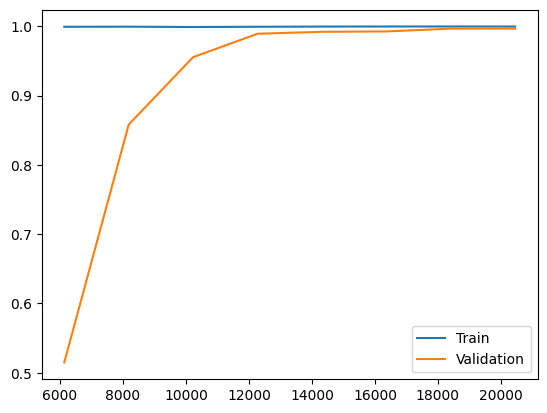

In [53]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    log_reg, X, y, cv=5, scoring="accuracy", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.legend(); plt.show()


In [44]:
from sklearn.calibration import calibration_curve

y_proba = log_reg.predict_proba(X)[:,1]
prob_true, prob_pred = calibration_curve(y, y_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("Predicted Probability"); plt.ylabel("True Probability")
plt.show()


ValueError: X has 5000 features, but LogisticRegression is expecting 10000 features as input.

In [54]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in tscv.split(X):
    log_reg.fit(X[train_idx], y.iloc[train_idx])
    print("Test Accuracy:", log_reg.score(X[test_idx], y.iloc[test_idx]))


Test Accuracy: 0.9892044121098333
Test Accuracy: 0.9223187045294532
Test Accuracy: 0.9990612532269421
Test Accuracy: 0.9978878197606196
Test Accuracy: 0.9997653133067355


In [55]:
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    if i == 1:  # 2nd split (index 1)
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        log_reg.fit(X_train, y_train)
        print("Fold:", i+1)
        print("Test Accuracy:", log_reg.score(X_test, y_test))

        # Predictions
        y_pred = log_reg.predict(X_test)

        # Misclassified indices
        misclassified_idx = test_idx[y_test != y_pred]

        # Print the actual messages + true/predicted labels
        misclassified_logs = df.iloc[misclassified_idx][["normalized_message", "is_fault"]].copy()
        misclassified_logs["predicted"] = y_pred[y_test != y_pred]

        print("\n🔹 Misclassified Logs in Fold 2:")
        print(misclassified_logs.to_string(index=False))

        break


Fold: 2
Test Accuracy: 0.9223187045294532

🔹 Misclassified Logs in Fold 2:
                                        normalized_message  is_fault  predicted
           Out of Memory: Killed process <PID> (sendmail).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <PID> (mysqld).      True      False
             Out of Memory: Killed process <P

In [57]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

def forecast_next_logs(log_reg, vectorizer, df, text_col="normalized_message", steps=10):
  
    # Ensure strings only
    df[text_col] = df[text_col].fillna("").astype(str)

    # Transform with vectorizer
    X = vectorizer.transform(df[text_col])

    # Get predicted fault probabilities
    scores = log_reg.predict_proba(X)[:, 1]

    # Forecast next scores with ARIMA
    model = ARIMA(scores, order=(2,1,2))
    fitted = model.fit()

    forecast_scores = fitted.forecast(steps=steps)
    return forecast_scores


In [59]:
next_scores = forecast_next_logs(log_reg, vectorizer, df, steps=10)
print("Next 10 forecasted scores:", next_scores)

Next 10 forecasted scores: [0.64945479 0.39028254 0.64166204 0.40558397 0.62746622 0.41893021
 0.61492286 0.4307191  0.60384306 0.44113245]
